
# Advanced ODOMENU Vehicle State Analysis

This notebook performs:

1. Velocity & acceleration plots
2. Speed vs time
3. Yaw vs time
4. IMU vs fused yaw-rate comparison
5. MPC-ready state vector export
6. Noise statistics analysis


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:

# Load odomenu
odom = pd.read_csv("odomenu.csv", skiprows=1)

# OPTIONAL: Load corrimu if available for comparison
try:
    imu = pd.read_csv("corrimu.csv", skiprows=1)
except:
    imu = None

odom.head()


,time,pos_x,pos_y,pos_z,qx,qy,qz,qw,vel_x,vel_y,...,ang_vel_y,ang_vel_z,acc_x,acc_y,acc_z,fusion_status,imu_bias_status,gnss1_status,gnss2_status,wheelspeed_status
0,1.771241e+09,22.2799,21.6129,-1.9596,0.002818,0.003587,-0.75142,-0.659809,-0.0002,-0.0006,...,0.00127,0.00025,0.0176,-0.0833,9.8076,4,1,8,8,-1
1,1.771241e+09,22.2799,21.6129,-1.9596,0.002818,0.003587,-0.75142,-0.659809,-0.0002,-0.0006,...,-0.00264,-0.00010,-0.0069,-0.0951,9.7963,4,1,8,8,-1
2,1.771241e+09,22.2799,21.6129,-1.9596,0.002818,0.003587,-0.75142,-0.659809,-0.0002,-0.0006,...,-0.00004,-0.00047,-0.0052,-0.1043,9.8028,4,1,8,8,-1
3,1.771241e+09,22.2799,21.6129,-1.9596,0.002818,0.003587,-0.75142,-0.659809,-0.0002,-0.0006,...,0.00153,-0.00036,0.0110,-0.1025,9.8073,4,1,8,8,-1
4,1.771241e+09,22.2799,21.6129,-1.9596,0.002818,0.003587,-0.75142,-0.659809,-0.0002,-0.0006,...,0.00039,-0.00007,0.0090,-0.0895,9.7990,4,1,8,8,-1


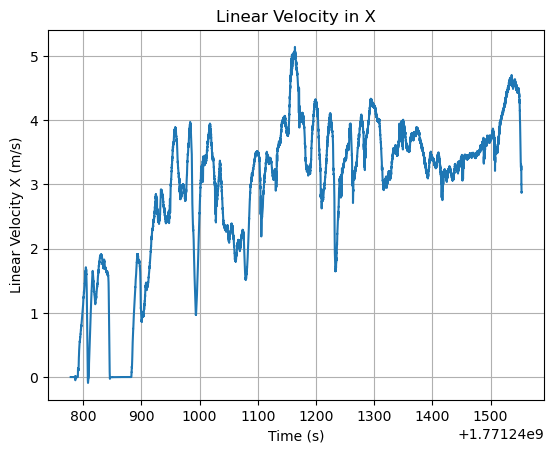

In [3]:

plt.figure()
plt.plot(odom["time"], odom["vel_x"])
plt.xlabel("Time (s)")
plt.ylabel("Linear Velocity X (m/s)")
plt.title("Linear Velocity in X")
plt.grid()
plt.show()


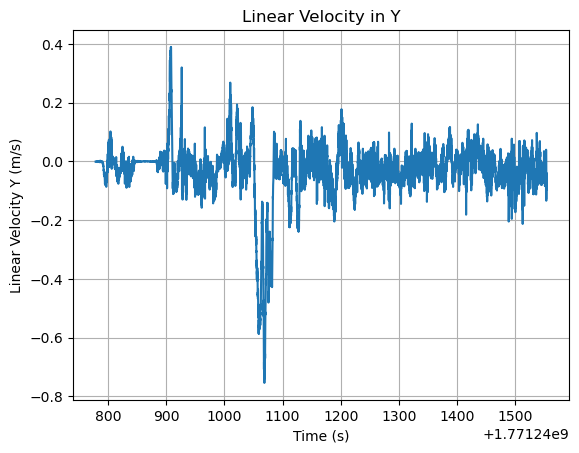

In [4]:

plt.figure()
plt.plot(odom["time"], odom["vel_y"])
plt.xlabel("Time (s)")
plt.ylabel("Linear Velocity Y (m/s)")
plt.title("Linear Velocity in Y")
plt.grid()
plt.show()


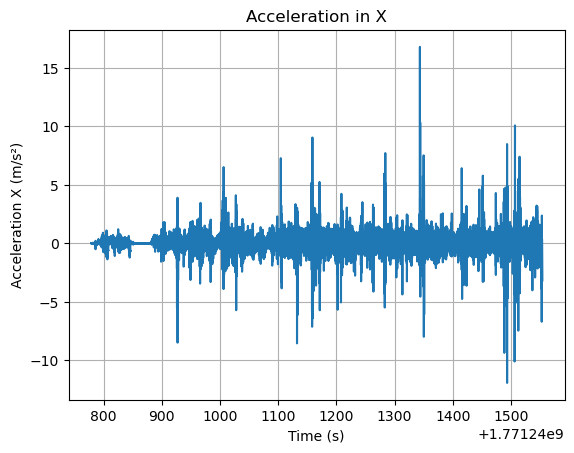

In [5]:

plt.figure()
plt.plot(odom["time"], odom["acc_x"])
plt.xlabel("Time (s)")
plt.ylabel("Acceleration X (m/s²)")
plt.title("Acceleration in X")
plt.grid()
plt.show()


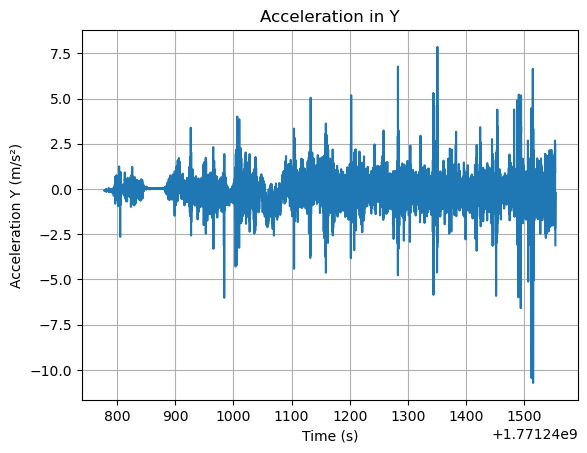

In [6]:

plt.figure()
plt.plot(odom["time"], odom["acc_y"])
plt.xlabel("Time (s)")
plt.ylabel("Acceleration Y (m/s²)")
plt.title("Acceleration in Y")
plt.grid()
plt.show()


In [7]:

# Speed magnitude
odom["speed"] = np.sqrt(odom["vel_x"]**2 + odom["vel_y"]**2)

# Yaw from quaternion
qw = odom["qw"]
qx = odom["qx"]
qy = odom["qy"]
qz = odom["qz"]

odom["yaw"] = np.arctan2(
    2 * (qw * qz + qx * qy),
    1 - 2 * (qy**2 + qz**2)
)

# Yaw rate
odom["yaw_rate"] = odom["ang_vel_z"]

# Acceleration magnitude
odom["acc_mag"] = np.sqrt(odom["acc_x"]**2 + odom["acc_y"]**2)

odom[["speed", "yaw", "yaw_rate", "acc_mag"]].head()


,speed,yaw,yaw_rate,acc_mag
0,0.000632,1.700449,0.00025,0.085139
1,0.000632,1.700449,-0.00010,0.095350
2,0.000632,1.700449,-0.00047,0.104430
3,0.000632,1.700449,-0.00036,0.103089
4,0.000632,1.700449,-0.00007,0.089951


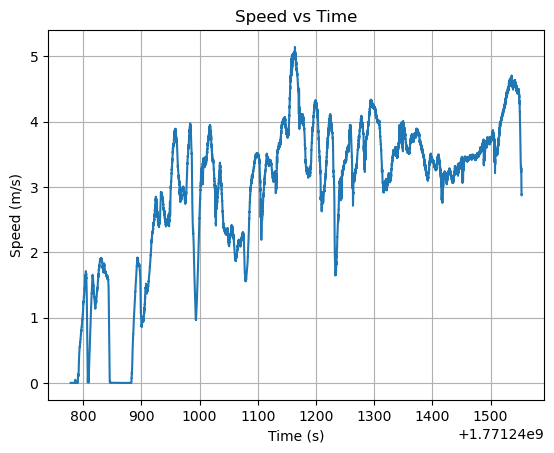

In [8]:

plt.figure()
plt.plot(odom["time"], odom["speed"])
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.title("Speed vs Time")
plt.grid()
plt.show()


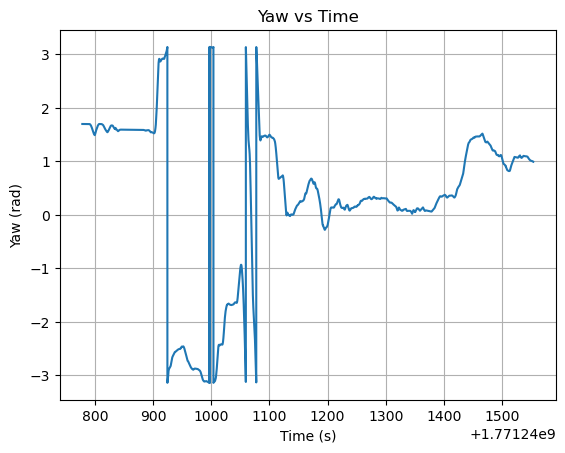

In [9]:

plt.figure()
plt.plot(odom["time"], odom["yaw"])
plt.xlabel("Time (s)")
plt.ylabel("Yaw (rad)")
plt.title("Yaw vs Time")
plt.grid()
plt.show()


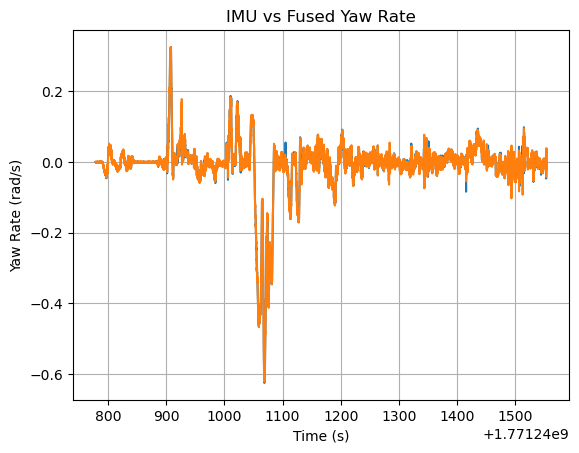

In [10]:

if imu is not None:
    imu_interp = np.interp(odom["time"], imu["time"], imu["ang_vel_z"])
    
    plt.figure()
    plt.plot(odom["time"], odom["yaw_rate"])
    plt.plot(odom["time"], imu_interp)
    plt.xlabel("Time (s)")
    plt.ylabel("Yaw Rate (rad/s)")
    plt.title("IMU vs Fused Yaw Rate")
    plt.grid()
    plt.show()


In [11]:

mpc_dataset = odom[["time", "pos_x", "pos_y", "yaw", "speed", "yaw_rate", "acc_x"]].copy()
mpc_dataset.to_csv("mpc_ready_dataset.csv", index=False)
mpc_dataset.head()


,time,pos_x,pos_y,yaw,speed,yaw_rate,acc_x
0,1.771241e+09,22.2799,21.6129,1.700449,0.000632,0.00025,0.0176
1,1.771241e+09,22.2799,21.6129,1.700449,0.000632,-0.00010,-0.0069
2,1.771241e+09,22.2799,21.6129,1.700449,0.000632,-0.00047,-0.0052
3,1.771241e+09,22.2799,21.6129,1.700449,0.000632,-0.00036,0.0110
4,1.771241e+09,22.2799,21.6129,1.700449,0.000632,-0.00007,0.0090


In [12]:

print("Velocity Noise Statistics:")
print(odom[["vel_x", "vel_y"]].std())

print("\nYaw Rate Noise Statistics:")
print(odom["yaw_rate"].std())

print("\nAcceleration Noise Statistics:")
print(odom[["acc_x", "acc_y"]].std())


Velocity Noise Statistics:
vel_x    1.190790
vel_y    0.096482
dtype: float64

Yaw Rate Noise Statistics:
0.07954710674309551

Acceleration Noise Statistics:
acc_x    0.825585
acc_y    0.729968
dtype: float64
